IA & Data science (LU3IN0226) -- 2025-2026
--------
*&copy; Equipe pédagogique: Christophe Marsala, Olivier Schwander, Jean-Noël Vittaut, Maxellende Julienne.*


# TD-TME08: arbres de décision numériques, et arbres de décision généraux

L'objectif de ce TP est d'implémenter de compléter l'algorithme de construction d'arbres de décision pour traiter des attributs numériques.

<font color="RED" size="+1">**[Q]**</font> **Indiquer dans la boîte ci-dessous vos noms et prénoms :**

PARANT Alexandre
Marc-Antoine XIA


<font color="RED" size="+1"><b>[Q]</b></font> **Renommer ce fichier ipython**

Tout en haut de cette page, cliquer sur <tt>tme-08</tt> et rajouter à la suite de <tt>tme-08</tt> les noms des membres du binômes séparés par un tiret.

<font color="RED" size="+1">IMPORTANT: soumission de votre fichier final</font>

**Nom à donner au fichier à poster** : *tme-08-Nom1_Nom2.ipynb* 
- *Nom1* et *Nom2* : noms des membres du binôme
- ne pas compresser ou faire une archive: il faut rendre le fichier ipython tel quel, éventuellement, si vous avez d'autres fichiers vous les rendez séparément.

**Echancier pour la soumission de votre compte-rendu:**
- le compte-rendu d'une séance doit être remis obligatoirement <font color="RED">avant la séance suivante</font>.

**Le compte-rendu est soumis sur la page Moodle.**


## Préparation

L'archive récupérée avec ce fichier contient aussi le répertoire <code>data</code> qui contient les bases pour expérimenter vos fonctions.

In [1]:
# - - - - - - - - - - - - - - - - - -
# imports utiles
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mtpl
import graphviz as gv
%matplotlib inline  

import math
import time
import sys

# Les instructions suivantes sont utiles pour recharger automatiquement 
# le code modifié dans les librairies externes
%load_ext autoreload
%autoreload 2

# - - - - - - - - - - - - - - - - - -
# Information sur l'environnent utilisé ici:
print("Version python et des librairies:")
print("\tPython ",sys.version)
print("\tpandas: ",pd.__version__)
print("\tnumpy: ",np.__version__)
print("\tmatplotlib: ",mtpl.__version__)

Version python et des librairies:
	Python  3.14.4 (main, Apr  8 2026, 17:48:49) [GCC 15.2.1 20260209]
	pandas:  2.3.3
	numpy:  2.4.4
	matplotlib:  3.10.9


In [4]:
# Importation de votre librairie iads:
# La ligne suivante permet de préciser le chemin d'accès à la librairie iads
import sys
sys.path.append('../')   # iads doit être dans le répertoire père du répertoire courant !

# Importation de la librairie iads
import iads as iads

# importation de Classifiers
from iads import Classifiers as cl

# importation de utils
from iads import utils as ut

# importation de evaluation
from iads import evaluation as ev



On introduit dans ce TME la librairie Python seaborn (voir: <a href="https://seaborn.pydata.org/">https://seaborn.pydata.org/</a>) qui offre des outils de visualisation assez intéressants. On l'utilise aussi pour accéder à des jeux de données classiques.

Si nécessaire, vous devrez installer cette librairie avec `pip` (cf. TME précédents) sur votre machine.


In [5]:
# Importation de la librairie seaborn:
import seaborn as sns


## Arbres de décision numériques

Pour tester la construction d'arbres de décision numériques, on utilise la base des Iris de Fischer (4 variables de description numériques, et 3 valeurs de classes à reconnaître).

### Premier contact avec les données: visualisation

In [6]:
# Le dataset des iris est fourni dans le package seaborn, on l'obtient ainsi:
iris_df = sns.load_dataset('iris')

# Contenu du dataframe :
iris_df

# Remarque: dans ce dataframe, la colonne "species" est la colonne de la classe. 
# C'est la seule colonne qui ne contient pas de valeurs réelles.

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


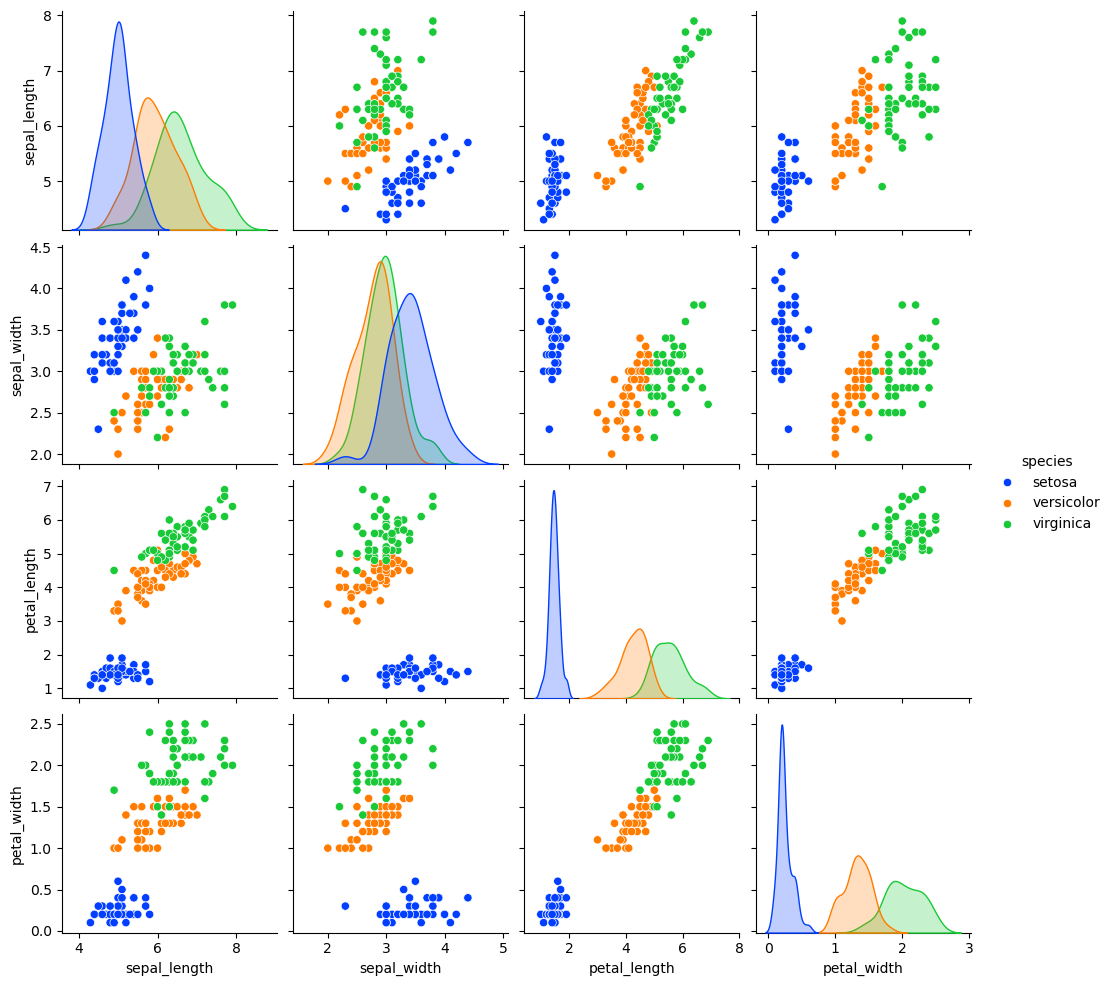

In [7]:
# Seaborn, permet de visualiser le jeu de données en construisant un corrélogramme:
sns.pairplot(iris_df,hue='species',palette='bright')


<font color="RED" size="+1"><b>[Q]</b></font> Examiner ce corrélogramme et expliquer ce qu'il représente:
- pourquoi certains affichages représentent des points et d'autres des courbes ?

De plus, en examinant ce corrélogramme : 
- est-ce que le problème de classification des iris semble être un problème difficile ? Expliquez ?
- à votre avis, sans faire de calculs, quels sont les 2 variables qui semblent les plus discrimantes pour reconnaître la valeur de la classe ?

<i>Rajouter ci-dessous une boîte "markdown" pour donner vos réponses.</i>

Il semble être un problème relativement facile notamment le setosa qui a des caractéristiques très différentes.

Le versicolor et le viriginica posent pas trop de problème sur les attributs petal_width et petal_length qui permettront leur différenciation.

### Préparation des données

In [8]:
# Passer du dataframe à des arrays:
iris_desc = np.array(iris_df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']])
iris_label = np.array(iris_df['species']) # species est la colonne contenant le label/la classe.

# obtenir les noms des colonnes :
iris_noms = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

print("Noms des features: ",iris_noms)
print("Noms des labels: ",np.unique(iris_label))

Noms des features:  ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Noms des labels:  ['setosa' 'versicolor' 'virginica']


In [9]:
# Exemple : fleurs dont la 'sepal_length' vaut 6.3
iris_label[iris_desc[:,0] == 6.3]

array(['versicolor', 'versicolor', 'versicolor', 'virginica', 'virginica',
       'virginica', 'virginica', 'virginica', 'virginica'], dtype=object)

<font color="RED" size="+1"><b>[Q]</b></font> Vérifier que la fonction <code>classe_majoritaire</code> et la fonction d'<code>entropie</code> écrites lors du TME précédent sont bien installées dans votre librairie `iads`, dans `classifiers.py`.



In [10]:
# Vérification sur nos données:
liste_classes = iris_label[iris_desc[:,0] == 6.3]
classe_majo = cl.classe_majoritaire(liste_classes)

print("Les classes: ", liste_classes)
print("Classe majoritaire: ", classe_majo)
print(f'Entropie: {cl.entropie(liste_classes):0.3f}')

Les classes:  ['versicolor' 'versicolor' 'versicolor' 'virginica' 'virginica'
 'virginica' 'virginica' 'virginica' 'virginica']
Classe majoritaire:  virginica
Entropie: 0.918


### Discrétisation des attributs numériques

<div class="alert alert-block alert-success">
    
Comme cela a été dit en cours, **discrétiser** un attribut numérique consiste en trouver un seuil de coupure dans son ensemble de valeurs après les avoir ordonnées.
</div>    


Ci-dessous, la méthode <code>discretise</code> qui permet de trouver le seuil de coupure optimal dans un ensemble de valeurs associées à des classes (labels).


In [11]:
def discretise(m_desc, m_class, num_col,verbose=False):
    """ input:
            - m_desc : (np.array) matrice des descriptions toutes numériques
            - m_class : (np.array) matrice des classes (correspondant à m_desc)
            - num_col : (int) numéro de colonne de m_desc à considérer
            - nb_classes : (int) nombre initial de labels dans le dataset (défaut: 2)
            verbose: pour afficher des messages de débuggage
        output: tuple : ((seuil_trouve, entropie), (liste_coupures,liste_entropies))
            -> seuil_trouve (float): meilleur seuil trouvé
            -> entropie (float): entropie du seuil trouvé (celle qui minimise)
            -> liste_coupures (List[float]): la liste des valeurs seuils qui ont été regardées
            -> liste_entropies (List[float]): la liste des entropies correspondantes aux seuils regardés
            (les 2 listes correspondent et sont donc de même taille)
            REMARQUE: dans le cas où il y a moins de 2 valeurs d'attribut dans m_desc, aucune discrétisation
            n'est possible, on rend donc ((None , +Inf), ([],[])) dans ce cas            
    """
    # Liste triée des valeurs différentes présentes dans m_desc:
    l_valeurs = np.unique(m_desc[:,num_col])
    
    # Si on a moins de 2 valeurs, pas la peine de discrétiser:
    if (len(l_valeurs) < 2):
        return ((None, float('Inf')), ([],[]))
    
    # Initialisation
    best_seuil = None
    best_entropie = float('Inf')
    
    # pour voir ce qui se passe, on va sauver les entropies trouvées et les points de coupures:
    liste_entropies = []
    liste_coupures = []
    
    nb_exemples = len(m_class)
    
    for v in l_valeurs:
        cl_inf = m_class[m_desc[:,num_col]<=v]
        cl_sup = m_class[m_desc[:,num_col]>v]
        nb_inf = len(cl_inf)
        nb_sup = len(cl_sup)
        
        # calcul de l'entropie de la coupure
        val_entropie_inf = cl.entropie(cl_inf) # entropie de l'ensemble des inf
        val_entropie_sup = cl.entropie(cl_sup) # entropie de l'ensemble des sup
        
        val_entropie = (nb_inf / float(nb_exemples)) * val_entropie_inf \
                       + (nb_sup / float(nb_exemples)) * val_entropie_sup
        
        # Ajout de la valeur trouvée pour retourner l'ensemble des entropies trouvées:
        liste_coupures.append(v)
        liste_entropies.append(val_entropie)
        if verbose:
            print(f"Discretise: coupure en {v} -> entropie de {val_entropie:1.4f}")
            
        # si cette coupure minimise l'entropie, on mémorise ce seuil et son entropie:
        if (best_entropie > val_entropie):
            best_entropie = val_entropie
            best_seuil = v
    if verbose:
        print(f"Discretise: *** meilleure coupure en {best_seuil} avec une entropie de {best_entropie:1.4f} ***")
    return (best_seuil, best_entropie), (liste_coupures,liste_entropies)

Discretise: coupure en 4.3 -> entropie de 0.9933
Discretise: coupure en 4.4 -> entropie de 0.9727
Discretise: coupure en 4.5 -> entropie de 0.9656
Discretise: coupure en 4.6 -> entropie de 0.9364
Discretise: coupure en 4.7 -> entropie de 0.9212
Discretise: coupure en 4.8 -> entropie de 0.8812
Discretise: coupure en 4.9 -> entropie de 0.8842
Discretise: coupure en 5.0 -> entropie de 0.8349
Discretise: coupure en 5.1 -> entropie de 0.7603
Discretise: coupure en 5.2 -> entropie de 0.7322
Discretise: coupure en 5.3 -> entropie de 0.7191
Discretise: coupure en 5.4 -> entropie de 0.6523
Discretise: coupure en 5.5 -> entropie de 0.6484
Discretise: coupure en 5.6 -> entropie de 0.6872
Discretise: coupure en 5.7 -> entropie de 0.6744
Discretise: coupure en 5.8 -> entropie de 0.8564
Discretise: coupure en 5.9 -> entropie de 0.8624
Discretise: coupure en 6.0 -> entropie de 0.8692
Discretise: coupure en 6.1 -> entropie de 0.8696
Discretise: coupure en 6.2 -> entropie de 0.8767
Discretise: coupure 

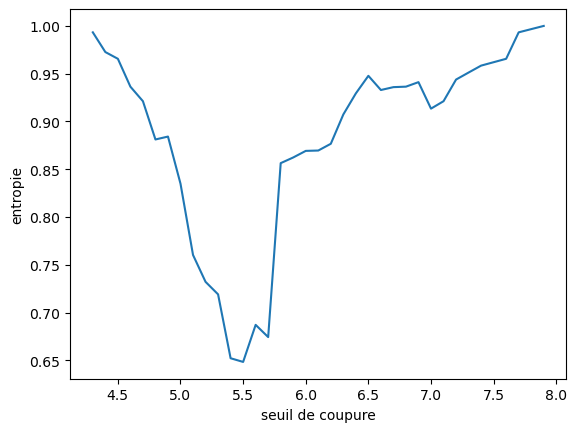

In [12]:
# Exemple d'utilisation:
numero_colonne = 0
resultat, liste_vals = discretise(iris_desc,iris_label,numero_colonne,verbose=True)

print("Pour ", iris_noms[numero_colonne])
print(f"Seuil de coupure trouvé: {resultat[0]:1.2f} et son entropie: {resultat[1]:1.4f}" )

# affichage de la variation de l'entropie en fonction du choix du seuil:
X,Y = liste_vals
plt.plot(X,Y)
plt.ylabel('entropie')
plt.xlabel('seuil de coupure')
plt.show()

Pour  petal_length
Seuil de coupure trouvé: 1.70 et son entropie: 0.4804


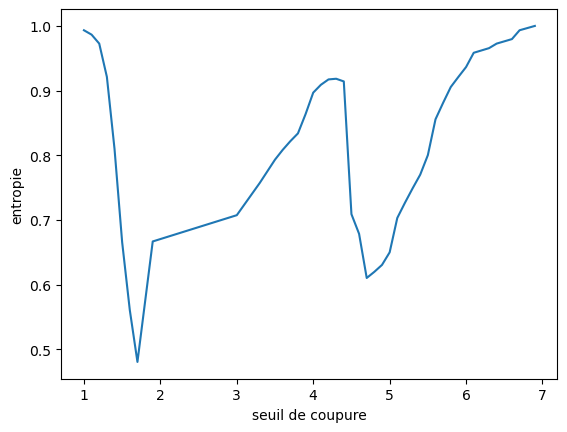

In [13]:
# Autre exemple:
numero_colonne = 2

resultat, liste_vals = discretise(iris_desc,iris_label,numero_colonne)

print("Pour ", iris_noms[numero_colonne])
print(f"Seuil de coupure trouvé: {resultat[0]:1.2f} et son entropie: {resultat[1]:1.4f}" )

# affichage de la variation de l'entropie en fonction du choix du seuil:
X,Y = liste_vals
plt.plot(X,Y)
plt.ylabel('entropie')
plt.xlabel('seuil de coupure')
plt.show()

<div class="alert alert-block alert-warning">
Une fois un seuil de coupure $s$ trouvé sur un attribut $n$, on partitionne la base d'apprentissage en 2 ensembles:
- l'ensemble des exemples qui ont une valeur inférieure ou égale à $s$ pour l'attribut $n$
- l'ensemble des exemples qui ont une valeur strictement supérieure à $s$ pour l'attribut $n$
</div>    


La fonction <code>partionne</code> ci-dessous prend en argument deux numpy array $m_{desc}$ et $m_{class}$ qui représentent une base d'apprentissage, un numéro de colonne $n$ et une valeur de seuil $s$ et rend un tuple composé  de 2 tuples de numpy arrays:
- le premier tuple est composé de l'ensemble des descriptions de tous les exemples de $T$ qui ont une valeur pour la colonne $n$ inférieure ou égale à $s$ et l'ensemble de leur classe;
- le second tuple est composé de l'ensemble des descriptions de tous les exemples de $T$ qui ont une valeur pour la colonne $n$ strictement supérieure à $s$ et l'ensemble de leur classe;


In [14]:
def partitionne(m_desc,m_class,n,s):
    """ input:
            - m_desc : (np.array) matrice des descriptions toutes numériques
            - m_class : (np.array) matrice des classes (correspondant à m_desc)
            - n : (int) numéro de colonne de m_desc
            - s : (float) seuil pour le critère d'arrêt
        Hypothèse: m_desc peut être partitionné ! (il contient au moins 2 valeurs différentes)
        output: un tuple composé de 2 tuples
    """
    return ((m_desc[m_desc[:,n]<=s], m_class[m_desc[:,n]<=s]), \
            (m_desc[m_desc[:,n]>s], m_class[m_desc[:,n]>s]))

In [15]:
# Exemple d'utilisation :

# Recherche point de coupure :
numero_colonne = 3
resultat, liste_vals = discretise(iris_desc,iris_label,numero_colonne)
print(f"Seuil de coupure trouvé: {resultat[0]:1.2f} et son entropie: {resultat[1]:1.4f}" )

# partitionnement :
((left_data,left_class), (right_data,right_class)) = partitionne(iris_desc,iris_label, numero_colonne,resultat[0])

print("Nombre d'exemples à gauche : ", len(left_class), " Nombre d'exemples à droite : ", len(right_class) )

Seuil de coupure trouvé: 0.50 et son entropie: 0.4547
Nombre d'exemples à gauche :  49  Nombre d'exemples à droite :  101


### Implémentation des arbres numériques

Afin de représenter des arbres de décision numériques, on créé une nouvelle classe qui permet de définir des noeuds internes de l'arbre associés à des attributs numériques.

<b>Remarque:</b> on se place ici dans le cas où l'arbre de décision final ne contiendra que des noeuds numériques. Il n'y a donc pas à prévoir de noeud catégoriel dans cet arbre (la version générale sera abordée un peu plus loin dans ce notebook).

<font color="RED" size="+1"><b>[Q]</b></font> Compléter la classe suivante pour pouvoir classifier avec un noeud numérique.

In [71]:
import graphviz as gv   # si ce n'a pas déjà été fait...

class NoeudNumerique:
    """ Classe pour représenter des noeuds numériques d'un arbre de décision
    """
    def __init__(self, num_att=-1, nom=''):
        """ Constructeur: il prend en argument
            - num_att (int) : le numéro de l'attribut auquel il se rapporte: de 0 à ...
              si le noeud se rapporte à la classe, le numéro est -1, on n'a pas besoin
              de le préciser
            - nom (str) : une chaîne de caractères donnant le nom de l'attribut si
              il est connu (sinon, on ne met rien et le nom sera donné de façon 
              générique: "att_Numéro")
        """
        self.__attribut = num_att    # numéro de l'attribut
        if (nom == ''):            # son nom si connu
            self.__nom_attribut = 'att_'+str(num_att)
        else:
            self.__nom_attribut = nom 
        self.__seuil = None          # seuil de coupure pour ce noeud
        self.__Les_fils = None       # aucun fils à la création, ils seront ajoutés
        self.__classe   = None       # valeur de la classe si c'est une feuille*

    def affiche_debug(self, profondeur=0):
        indent = "  " * profondeur
    
        print(indent + "----------------------")
    
        if self.est_feuille():
            print(indent + f"FEUILLE")
            print(indent + f"classe = {self.__classe}")
            print(indent + f"Les_fils = {self.__Les_fils}")
            return
    
        print(indent + f"NOEUD")
        print(indent + f"attribut = {self.__attribut}")
        print(indent + f"nom = {self.__nom_attribut}")
        print(indent + f"seuil = {self.__seuil}")
        print(indent + f"Les_fils keys = {list(self.__Les_fils.keys()) if self.__Les_fils else None}")
    
        if self.__Les_fils is not None:
            print(indent + "-> INF")
            self.__Les_fils['inf'].affiche_debug(profondeur + 1)
    
            print(indent + "-> SUP")
            self.__Les_fils['sup'].affiche_debug(profondeur + 1)
        
    def est_feuille(self):
        """ rend True si l'arbre est une feuille 
            c'est une feuille s'il n'a aucun fils
        """
        return self.__Les_fils == None
    
    def ajoute_fils(self, val_seuil, fils_inf, fils_sup):
        """ val_seuil : valeur du seuil de coupure
            fils_inf : fils à atteindre pour les valeurs inférieures ou égales à seuil
            fils_sup : fils à atteindre pour les valeurs supérieures à seuil
        """
        if self.__Les_fils == None:
            self.__Les_fils = dict()            
        self.__seuil = val_seuil
        self.__Les_fils['inf'] = fils_inf
        self.__Les_fils['sup'] = fils_sup        
    
    def ajoute_feuille(self,classe):
        """ classe: valeur de la classe
            Ce noeud devient un noeud feuille
        """
        self.__classe    = classe
        self.__Les_fils  = None   # normalement, pas obligatoire ici, c'est pour être sûr
        
    def classifie(self, exemple):
        """ exemple : numpy.array
            rend la classe de l'exemple (pour nous, soit +1, soit -1 en général)
            on rend la valeur 0 si l'exemple ne peut pas être classé (cf. les questions
            posées en fin de ce notebook)
        """
        if self.est_feuille():
            return self.__classe
            
        # descente récursive dans le noeud associé à la valeur de l'attribut
        # pour cet exemple:
        if exemple[self.__attribut] <= self.__seuil:
            # currentRoot = currentRoot._NoeudNumerique__Les_fils['inf']
            return self.__Les_fils['inf'].classifie(exemple)
        else:
            return self.__Les_fils['sup'].classifie(exemple)

    
    def compte_feuilles(self):
        """ rend le nombre de feuilles sous ce noeud
        """
        if self.est_feuille():
            return 1
        total = 0
        for noeud in self.__Les_fils:
            total += self.__Les_fils[noeud].compte_feuilles()
        return total
     
    def to_graph(self, g, prefixe='A'):
        """ construit une représentation de l'arbre pour pouvoir l'afficher graphiquement
            Cette fonction ne nous intéressera pas plus que ça, elle ne sera donc 
            pas expliquée            
        """
        if self.est_feuille():
            g.node(prefixe,str(self.__classe),shape='box')
        else:
            g.node(prefixe, str(self.__nom_attribut))
            self.__Les_fils['inf'].to_graph(g,prefixe+"g")
            self.__Les_fils['sup'].to_graph(g,prefixe+"d")
            g.edge(prefixe,prefixe+"g", '<='+ str(self.__seuil))
            g.edge(prefixe,prefixe+"d", '>'+ str(self.__seuil))                
        return g


Cet arbre contient  2  feuilles.


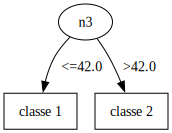

In [72]:
# Exemple d'utilisation: 
un_arbre= NoeudNumerique(nom='n1')
un_arbre.ajoute_feuille("classe 1")
un_arbre.est_feuille()
un_arbre1 = NoeudNumerique(nom="n2")
un_arbre1.ajoute_feuille("classe 2")
un_arbre2 = NoeudNumerique(nom="n3")
un_arbre2.ajoute_fils(42.0,un_arbre,un_arbre1)
print("Cet arbre contient ", un_arbre2.compte_feuilles()," feuilles.")

gtree = gv.Digraph(format='png')
un_arbre2.to_graph(gtree)



<font color="RED" size="+1"><b>[Q]</b></font> En utilisant la fonction `discretise`, compléter la fonction `construit_AD_num` (elle ressemble à la version catégorielle réalisée lors de la séance précédente) afin de pouvoir construire des arbres de décision avec des valeurs numériques.
Les attributs numériques seront discrétisés en 2 valeurs catégorielles.

In [80]:
def construit_AD_num(X,Y,epsilon,LNoms = [], verbose=False):
    """ X,Y : dataset
        epsilon : seuil d'entropie pour le critère d'arrêt 
        LNoms : liste des noms de features (colonnes) de description 
        verbose: pour afficher des messages de débuggage
    """
    
    # dimensions de X:
    (nb_lig, nb_col) = X.shape
    
    entropie_classe = cl.entropie(Y)
    
    if (entropie_classe <= epsilon) or  (nb_lig <=1):
        # ARRET : on crée une feuille
        noeud = NoeudNumerique(-1,"Label")  # On met la feuille dans un noeud catégoriel
        classe_choisie = cl.classe_majoritaire(Y)
        noeud.ajoute_feuille(classe_choisie)
        if verbose:
            print("AD: construction d'une feuille avec {classe_choisie}")
    else:
        gain_max = 0.0  # meilleur gain trouvé (initalisé à 0.0 => aucun gain)
        i_best = -1     # numéro du meilleur attribut (init à -1 (aucun))
        Xbest_tuple = None
        Xbest_seuil = None

        for attribut in range(X.shape[1]):
            (best_seuil, best_entropie), (liste_coupures,liste_entropies) = discretise(X, Y, attribut, verbose)
            if  entropie_classe - best_entropie > gain_max:
                gain_max = entropie_classe - best_entropie
                
                Xbest_seuil = best_seuil
                Xbest_tuple = partitionne(X, Y, attribut, Xbest_seuil)
                i_best = attribut
        
        ############ FIN
        if (i_best != -1): # Un attribut qui amène un gain d'information >0 a été trouvé
            if len(LNoms)>0:  # si on a des noms de features
                noeud = NoeudNumerique(i_best,LNoms[i_best]) 
            else:
                noeud = NoeudNumerique(i_best)
            ((left_data,left_class), (right_data,right_class)) = Xbest_tuple
            noeud.ajoute_fils( Xbest_seuil, \
                              construit_AD_num(left_data,left_class, epsilon, LNoms), \
                              construit_AD_num(right_data,right_class, epsilon, LNoms) )
        else: # aucun attribut n'a pu améliorer le gain d'information
              # ARRET : on crée une feuille
            noeud = NoeudNumerique(-1,"Label")
            noeud.ajoute_feuille(cl.classe_majoritaire(Y))
        
    return noeud

<font color="RED" size="+1"><b>[Q]</b></font> Compléter la classe `ClassifierArbreNumerique` ci-dessous, sur le modèle de la classe `ClassifierArbreDecision`.

In [81]:
class ClassifierArbreNumerique(cl.Classifier):
    """ Classe pour représenter un classifieur par arbre de décision numérique
    """
    
    def __init__(self, input_dimension, epsilon, LNoms=[]):
        """ Constructeur
            Argument:
                - intput_dimension (int) : dimension de la description des exemples
                - epsilon (float) : paramètre de l'algorithme (cf. explications précédentes)
                - LNoms : Liste des noms de dimensions (si connues)
            Hypothèse : input_dimension > 0
        """
        super().__init__(input_dimension)  # Appel du constructeur de la classe mère
        self.__epsilon = epsilon
        self.__LNoms = LNoms
        # l'arbre est manipulé par sa racine qui sera un Noeud
        self.__racine = None
        
    def __str__(self):
        """  -> str
            rend le nom du classifieur avec ses paramètres
        """
        return  super().__str__()+' - ArbreNumerique ['+str(super().get_dimension()) + '] eps='+str(self.__epsilon)
        
    def train(self, desc_set, label_set,verbose=False):
        """ Permet d'entrainer le modele sur l'ensemble donné
            desc_set: ndarray avec des descriptions
            label_set: ndarray avec les labels correspondants
            verbose: pour afficher des messages de débuggage
            Hypothèse: desc_set et label_set ont le même nombre de lignes
        """        

    
        self.__racine = construit_AD_num(desc_set, label_set, self.__epsilon, self.__LNoms, verbose)
    
   
    def score(self,x):
        """ rend le score de prédiction sur x (valeur réelle)
            x: une description
        """
        # cette méthode ne fait rien dans notre implémentation :
        pass
    
    def predict(self, x):
        """ x (array): une description d'exemple
            rend la prediction sur x             
        """
        return self.__racine.classifie(x)

    def accuracy(self, desc_set, label_set):  # Version propre aux arbres
        """ Permet de calculer la qualité du système sur un dataset donné
            desc_set: ndarray avec des descriptions
            label_set: ndarray avec les labels correspondants
            Hypothèse: desc_set et label_set ont le même nombre de lignes
        """
        return np.mean(label_set==np.apply_along_axis(self.predict, 1, desc_set))


    def number_leaves(self):
        """ rend le nombre de feuilles de l'arbre
        """
        return self.__racine.compte_feuilles()
    
    def affiche(self,GTree):
        """ affichage de l'arbre sous forme graphique
            Cette fonction modifie GTree par effet de bord
        """
        self.__racine.to_graph(GTree)

### Exemple d'application avec les iris

Cet arbre possède  11  feuilles.


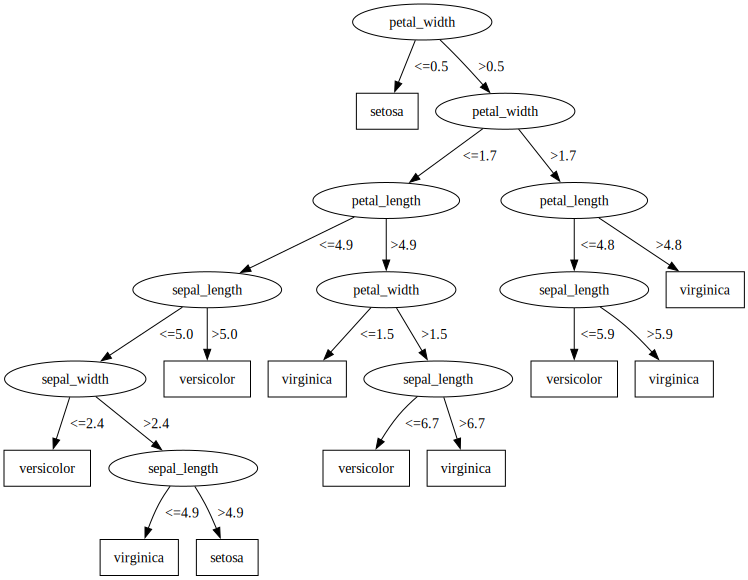

In [82]:
# Initialiation d'un arbre pour le dataset Iris:
arbre_iris = ClassifierArbreNumerique(len(iris_noms), 0.0, iris_noms)

# Construction de l'arbre de décision à partir du dataset Iris
arbre_iris.train(iris_desc,iris_label, False)

# Construction de la représentation graphique (affichage)
graphe_arbre_iris = gv.Digraph(format='png')
arbre_iris.affiche(graphe_arbre_iris)

# Affichage du graphe obtenu:
print("Cet arbre possède ",arbre_iris.number_leaves()," feuilles.")
graphe_arbre_iris

In [87]:

# mesure du taux de bonne classifications
arbre_iris.accuracy(iris_desc,iris_label)
arbre_iris._ClassifierArbreNumerique__racine.affiche_debug()

----------------------
NOEUD
attribut = 3
nom = petal_width
seuil = 0.5
Les_fils keys = ['inf', 'sup']
-> INF
  ----------------------
  FEUILLE
  classe = setosa
  Les_fils = None
-> SUP
  ----------------------
  NOEUD
  attribut = 3
  nom = petal_width
  seuil = 1.7
  Les_fils keys = ['inf', 'sup']
  -> INF
    ----------------------
    NOEUD
    attribut = 2
    nom = petal_length
    seuil = 4.9
    Les_fils keys = ['inf', 'sup']
    -> INF
      ----------------------
      NOEUD
      attribut = 0
      nom = sepal_length
      seuil = 5.0
      Les_fils keys = ['inf', 'sup']
      -> INF
        ----------------------
        NOEUD
        attribut = 1
        nom = sepal_width
        seuil = 2.4
        Les_fils keys = ['inf', 'sup']
        -> INF
          ----------------------
          FEUILLE
          classe = versicolor
          Les_fils = None
        -> SUP
          ----------------------
          NOEUD
          attribut = 0
          nom = sepal_length
       

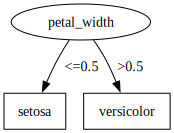

In [84]:
# Nouvel essai avec un seuil d'entropie élevé:
# Initialiation d'un arbre pour le dataset Elections:
arbre_iris2 = ClassifierArbreNumerique(len(iris_noms),0.75, iris_noms)

# Construction de l'arbre de décision à partir du dataset Elections
arbre_iris2.train(iris_desc,iris_label, False)

# Construction de la représentation graphique (affichage)
graphe_arbre_iris2 = gv.Digraph(format='png')
arbre_iris2.affiche(graphe_arbre_iris2)

# Affichage du graphe obtenu:
graphe_arbre_iris2

In [85]:
# mesure du taux de bonne classification
arbre_iris2.accuracy(iris_desc,iris_label)

np.float64(0.32666666666666666)

### Expérimentations

<font color="RED" size="+1"><b>[Q]</b></font> Tester cet algorithme en effectuant une validation croisée sur les données des iris (en prenant $0.0$ comme seuil d'entropie).

In [54]:
# ################### A COMPLETER 

tic = time.time()

arbre_iris3 = ClassifierArbreNumerique(len(iris_noms),0.0, iris_noms)

(res_all, res_moy, res_sd) = ev.validation_croisee(arbre_iris3, (iris_desc, iris_label), 10)


toc = time.time()
# ################### 
       
print("\nValidation croisée sur les iris avec comme seuil ",0.0)
print("Perf obtenues : ",res_all)
print(f'\nAccuracy moyenne: {res_moy:.3f}\técart type: {res_sd:.3f}')
print(f'Temps mis: {(toc-tic):.3f}s')

[7.9 3.8 6.4 2. ] [NOEUD] attr=petal_width (id=3) seuil=0.5 fils=OK)
[7.9 3.8 6.4 2. ] [NOEUD] attr=petal_width (id=3) seuil=1.6 fils=OK)
[7.9 3.8 6.4 2. ] [NOEUD] attr=petal_length (id=2) seuil=4.8 fils=OK)
[6.6 3.  4.4 1.4] [NOEUD] attr=petal_width (id=3) seuil=0.5 fils=OK)
[6.6 3.  4.4 1.4] [NOEUD] attr=petal_width (id=3) seuil=1.6 fils=OK)
[6.6 3.  4.4 1.4] [NOEUD] attr=petal_length (id=2) seuil=5.1 fils=OK)
[6.6 3.  4.4 1.4] [NOEUD] attr=sepal_width (id=1) seuil=3.4 fils=OK)
[6.6 3.  4.4 1.4] [NOEUD] attr=petal_length (id=2) seuil=4.9 fils=OK)
[5.6 3.  4.5 1.5] [NOEUD] attr=petal_width (id=3) seuil=0.5 fils=OK)
[5.6 3.  4.5 1.5] [NOEUD] attr=petal_width (id=3) seuil=1.6 fils=OK)
[5.6 3.  4.5 1.5] [NOEUD] attr=petal_length (id=2) seuil=5.1 fils=OK)
[5.6 3.  4.5 1.5] [NOEUD] attr=sepal_width (id=1) seuil=3.4 fils=OK)
[5.6 3.  4.5 1.5] [NOEUD] attr=petal_length (id=2) seuil=4.9 fils=OK)
[4.8 3.  1.4 0.3] [NOEUD] attr=petal_width (id=3) seuil=0.5 fils=OK)
[5.2 3.5 1.5 0.2] [NOEUD] att

<font color="RED" size="+1"><b>[Q]</b></font> Etudier la variation du taux de bonne classification lorsque l'on fait varier le seuil d'entropie utilisé pour l'apprentissage. Tracer ensuite la courbe de l'accuracy moyenne (incluant son écart type) quand le seuil d'entropie varie.

In [100]:
veps = np.arange(0, 1+0.101, 0.101)
vacc = []
for eps in veps:
    arbre_iris3 = ClassifierArbreNumerique(len(iris_noms),eps, iris_noms)
    (res_all, res_moy, res_sd) = ev.validation_croisee(arbre_iris3, (iris_desc, iris_label), 10)
    print(f"seuil d'entropie = {eps}           accuracy moyenne: {res_moy}           écart type: {res_sd})")
    vacc.append(res_moy)



seuil d'entropie = 0.0           accuracy moyenne: 0.5733333333333333           écart type: 0.30724582991474436)
seuil d'entropie = 0.101           accuracy moyenne: 0.7           écart type: 0.22949219304078006)
seuil d'entropie = 0.202           accuracy moyenne: 0.6533333333333333           écart type: 0.29333333333333333)
seuil d'entropie = 0.30300000000000005           accuracy moyenne: 0.6066666666666667           écart type: 0.19652537297311565)
seuil d'entropie = 0.404           accuracy moyenne: 0.6399999999999999           écart type: 0.2893671255228094)
seuil d'entropie = 0.505           accuracy moyenne: 0.64           écart type: 0.21540659228538017)
seuil d'entropie = 0.6060000000000001           accuracy moyenne: 0.5733333333333333           écart type: 0.2444040370643115)
seuil d'entropie = 0.7070000000000001           accuracy moyenne: 0.52           écart type: 0.16275407487644936)
seuil d'entropie = 0.808           accuracy moyenne: 0.5133333333333333           écart

Pour pouvoir afficher la courbe des variations de l'accuracy en affichant aussi l'écart type correspondant à chaque valeur, on utilise la fonction `lineplot` de seaborn, pour cela, il est nécessaire dans un premier temps de mettre les résultats obtenus dans un dataframe :
- avec 2 colonnes: 'Entropie' et 'Accuracy'
- chaque ligne donne le résultat d'un taux de bonne classification obtenu dans la validation croisée pour une valeur de seuil d'entropie : il y a donc 10 lignes par seuil d'entropie, chaque ligne avec le résultat d'une étape de la validation croisée.

<font color="RED" size="+1"><b>[Q]</b></font> Construire le dataframe ainsi défini.

In [101]:
df_res = pd.DataFrame(columns=['Entropie', 'Accuracy'])

df_res['Accuracy'] = vacc
df_res['Entropie'] = veps
# Le datataframe obtenu :
df_res

,Entropie,Accuracy
0,0.000,0.573333
1,0.101,0.700000
2,0.202,0.653333
3,0.303,0.606667
4,0.404,0.640000
5,0.505,0.640000
6,0.606,0.573333
7,0.707,0.520000
8,0.808,0.513333
9,0.909,0.526667


L'affichage se fait avec la fonction `lineplot` de seaborn. 

**Remarque**: le calcul de la moyenne et de l'écart type pour une même valeur de seuil est géré par la fonction.

<AxesSubplot: xlabel='Entropie', ylabel='Accuracy'>

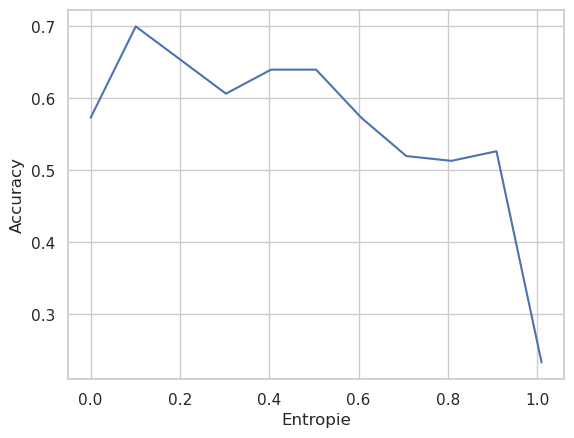

In [102]:
# Tracé avec lineplot de seaborn:
sns.set_theme(style="whitegrid")
sns.lineplot(x="Entropie", y="Accuracy", data=df_res)

## Frontière de décision

Visualiser la frontière de séparation des classes produite par un arbre de décision numérique:

1. générer un dataset aléatoire (gaussien) comme fait en TME 4 et séparer en train/test
2. afficher la frontière avec `plot_frontiere` et afficher les exemples avec `plot2DTrainTestSet`


On pourra comparer avec le résultat obtenu avec le perceptron stable.

### Génération du dataset

Taille du dataset gaussien généré :(200, 2) exemples
Base d'apprentissage: (150, 2) et 150 labels
Base de test: (50, 2) et 50 labels


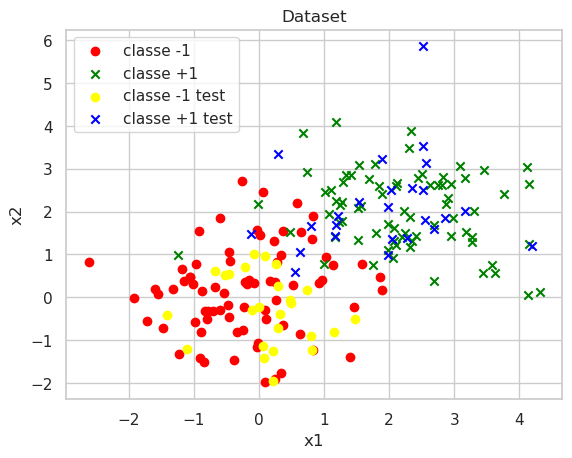

In [103]:
# Exemple d'utilisation:
np.random.seed(42)   # on prend 42 comme graine

# Génération d'un dataset gaussien avec 200 exemples au total
X_gauss, Y_gauss = ut.genere_dataset_gaussian(np.array([2,2]) ,np.array([[1,0],[0,1]]), \
                                                       np.array([0,0]), np.array([[1,0],[0,1]]), \
                                                       100)

print(f"Taille du dataset gaussien généré :{np.shape(X_gauss)} exemples")

# Découpage en train/test du dataset gaussien
(train_desc, train_label), (test_desc, test_label) = ut.genere_train_test(X_gauss, Y_gauss,75,75)

print(f"Base d'apprentissage: {train_desc.shape} et {len(train_label)} labels")
print(f"Base de test: {test_desc.shape} et {len(test_label)} labels")

# Affichage :
ut.plot2DTrainTestSet(train_desc, train_label,test_desc, test_label)

### Frontière de décision et résultat avec le perceptron stable

Classifier #49 (d2) (TME3): initialisation (learning rate= 0.01) w= [-0.00025092  0.00090143]
Apprentissage:
train (TME3) (2, 0.01, array([0.00053306, 0.00104045])) : 420 appels à train_step
Accuracy Train:	0.7733
Accuracy Test:	0.7600


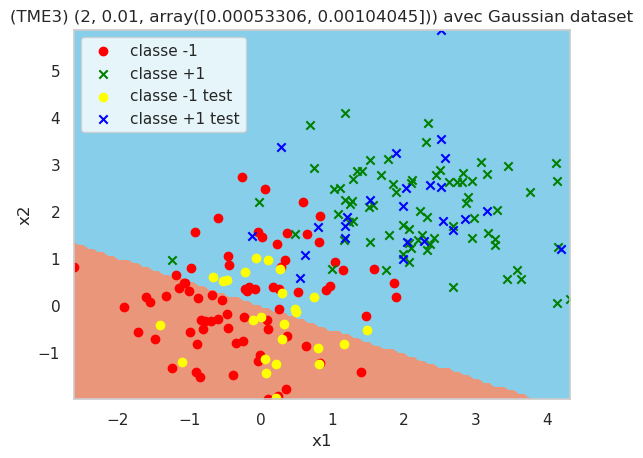

In [104]:
# Réinitialisation de la graine pour la mise au point (à enlever ensuite !)
np.random.seed(42)   # on prend 42 comme graine

# De même, les classes de Classifiers sont utilisables en mettant cl. devant leur nom:
# Création d'un perceptron
perceptronV1 = cl.ClassifierPerceptronTME3(2, learning_rate=0.01, init=False, verbose=True)

print("Apprentissage:")
perceptronV1.train(train_desc,train_label,nb_max=1000,verbose=True)

print(f"Accuracy Train:\t{perceptronV1.accuracy(train_desc,train_label):1.4f}")
print(f"Accuracy Test:\t{perceptronV1.accuracy(test_desc,test_label):1.4f}")

# Affichage de la frontière de séparation des classes
ut.plot_frontiere(X_gauss, Y_gauss,perceptronV1,step=100)
ut.plot2DTrainTestSet(train_desc,train_label,test_desc,test_label, nom_dataset=f"{perceptronV1} avec Gaussian dataset")

### Frontière de décision et résultat avec un arbre de décision numérique

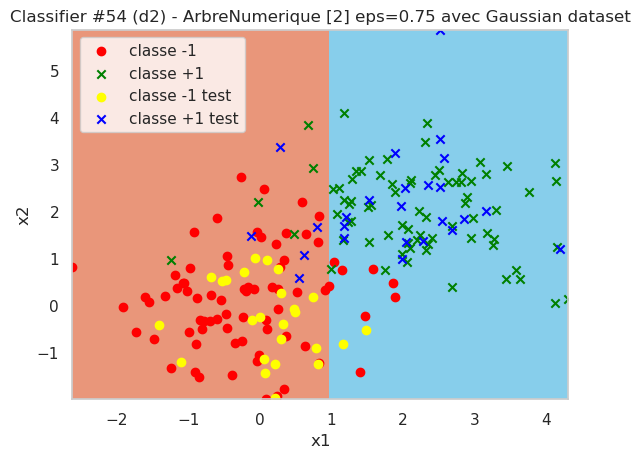

In [109]:
# Réinitialisation de la graine pour la mise au point (à enlever ensuite !)
np.random.seed(42)   # on prend 42 comme graine

# ################### A COMPLETER 
arbreNum1 = ClassifierArbreNumerique(len([-1, 1]),0.75, [-1, 1])

# Construction de l'arbre de décision à partir du dataset Elections
arbreNum1.train(train_desc,train_label)


# ################### 
# Affichage de la frontière de séparation des classes
ut.plot_frontiere(X_gauss, Y_gauss,arbreNum1,step=300)
ut.plot2DTrainTestSet(train_desc,train_label,test_desc,test_label, nom_dataset=f"{arbreNum1} avec Gaussian dataset")

## Comparaison avec d'autres algorithmes

<font color="RED" size="+1"><b>[Q]</b></font> Comparer les résultats obtenus avec la validation croisée avec les résultats obtenus avec les autres classifieurs (numériques) que vous avez implémentés.

## Arbres généraux

La version générale d'un classifieur par arbre de décision doit pouvoir gérer des datasets contenant à la fois des variables numériques mais aussi catégorielles. 

Pour connaître le type d'une variable (numérique ou catégorielle) on utilise une liste de booléen qui dit pour chaque variable si elle est numérique (True) ou catégorielle (False). Cette liste (que l'on va nommer `LTypes`) sera passée en argument.


<font color="RED" size="+1"><b>[Q]</b></font> La fonction `construit_AD_gen` est une version générale des fonctions `construit_AD` et `construit_AD_num`.


 Compléter la fonction  `construit_AD_gen` suivante pour qui prend les mêmes arguments que les fonctions précédentes avec en plus, la liste de booléens qui donne le type de chaque variable.

In [ ]:
def construit_AD_gen(X,Y,epsilon, LNoms, LTypes,verbose=False):
    """ X,Y : dataset
        epsilon : seuil d'entropie pour le critère d'arrêt 
        LNoms : liste des noms de features (colonnes) de description 
        LTypes: liste de booléens qui donne le type des features :
                LTypes[i] est True si LNoms[i] est un attribut numérique
                LTypes[i] est False si LNoms[i] est un attribut symbolique
        verbose: pour afficher des messages de débuggage
        Hypothèse: len(LTypes) >0 et len(LNoms]>0
    """
    
    # dimensions de X:
    (nb_lig, nb_col) = X.shape
    entropie_classe = cl.entropie(Y)
    
    if (entropie_classe <= epsilon) or  (nb_lig <=1):
        # ARRET : on crée une feuille
        noeud = NoeudNumerique(-1,"Label")
        if len(Y) <1:
            noeud.ajoute_feuille(None)    
        else:
            noeud.ajoute_feuille(cl.classe_majoritaire(Y))
    else:
        LCols_num = [i for i in range(0,len(LTypes)) if LTypes[i]]
        if len(LCols_num) == 0: # Pas d'attributs numériques
            return cl.construit_AD(X,Y,epsilon,LNoms)
            
        LCols_cat = [i for i in range(0,len(LTypes)) if not(LTypes[i])]
        if len(LCols_cat) == 0: # Pas d'attributs catégoriels
            ##################
            ## COMPLETER ICI !
            ##################

        gain_max = 0.0  # meilleur gain trouvé (initalisé à 0.0 => aucun gain)
        i_best = -1     # numéro du meilleur attribut (init à -1 (aucun))        
        #############
        for i in range(0,X.shape[1]):
            if LTypes[i]:  # attribut numérique
                ##################
                ## COMPLETER ICI !
                ##################
            else: # attribut catégoriel
                ##################
                ## COMPLETER ICI !
                ##################

            if verbose:
                nom = str(i)
                if LNoms != []:
                    nom = LNoms[i]
                print(f"\tattribut {nom}: entropie= {entropie_Xi:1.5f}")

        ############
        if (i_best != -1): # Un attribut qui amène un gain d'information >0 a été trouvé
            if LTypes[i_best]:
                ##################
                ## COMPLETER ICI !
                ##################
            else:
                ##################
                ## COMPLETER ICI !
                ##################

        ###########################################################        
        else: # aucun attribut n'a pu améliorer le gain d'information
              # ARRET : on crée une feuille
            noeud = cl.NoeudCategoriel(-1,"Label")
            noeud.ajoute_feuille(cl.classe_majoritaire(Y))
        
    return noeud

<font color="RED" size="+1"><b>[Q]</b></font> Compléter la classe `ClassifierArbreGeneral` pour construire un classifieur par arbre de décision général.

In [ ]:
class ClassifierArbreGeneral(cl.Classifier):
    """ Classe pour représenter un classifieur par arbre de décision (numérique ou catégoriel)
    """
    
    def __init__(self, input_dimension, epsilon, LNoms=[], LTypes=[]):
        """ Constructeur
            Argument:
                - intput_dimension (int) : dimension de la description des exemples
                - epsilon (float) : paramètre de l'algorithme (cf. explications précédentes)
                - LNoms : Liste des noms de dimensions (si connues)
            LTypes: liste de booléens qui donne le type des features :
                LTypes[i] est True si LNoms[i] est un attribut numérique
                LTypes[i] est False si LNoms[i] est un attribut symbolique
                si la liste est vide, on considère que tous les attributs 
                sont numériques (comme si la liste ne contenait que des True)
            Hypothèses : 
                - input_dimension > 0
                - si len(LTypes) vaut soit 0 (vide), soit input_dimension
                - si len(Noms) vaut soit 0 (vide), soit input_dimension
            
        """
        super().__init__(input_dimension)  # Appel du constructeur de la classe mère
        self.__dimension = input_dimension
        self.__epsilon = epsilon
        
        if len(LNoms) == 0:
            self.__LNoms = ['att_'+str(i) for i in range(0,input_dimension)]
        else:
            self.__LNoms = LNoms
            
        if len(LTypes) == 0:
            ##################
            ## COMPLETER ICI !
            ##################
        else:
            self.__LTypes = LTypes        
        self.__racine = None
        
    def __str__(self):
        """  -> str
            rend le nom du classifieur avec ses paramètres
        """
        return  super().__str__()+' - ArbreGeneral ['+str(super().get_dimension()) + '] eps='+str(self.__epsilon)
        
    def train(self, desc_set, label_set,verbose=False):
        """ Permet d'entrainer le modele sur l'ensemble donné
            desc_set: ndarray avec des descriptions
            label_set: ndarray avec les labels correspondants
            verbose: pour afficher des messages de débuggage
            Hypothèse: desc_set et label_set ont le même nombre de lignes
        """        
        ##################
        ## COMPLETER ICI !
        ##################
   
    def score(self,x):
        """ rend le score de prédiction sur x (valeur réelle)
            x: une description
        """
        # cette méthode ne fait rien dans notre implémentation :
        pass
    
    def predict(self, x):
        """ x (array): une description d'exemple
            rend la prediction sur x             
        """
        ##################
        ## COMPLETER ICI !
        ##################

    def accuracy(self, desc_set, label_set):  # Version propre à aux arbres
        """ Permet de calculer la qualité du système sur un dataset donné
            desc_set: ndarray avec des descriptions
            label_set: ndarray avec les labels correspondants
            Hypothèse: desc_set et label_set ont le même nombre de lignes
        """
        ##################
        ## COMPLETER ICI !
        ##################

    def number_leaves(self):
        """ rend le nombre de feuilles de l'arbre
        """
        return self.__racine.compte_feuilles()
    
    def affiche(self,GTree):
        """ affichage de l'arbre sous forme graphique
            Cette fonction modifie GTree par effet de bord
        """
        self.__racine.to_graph(GTree)
# ---------------------------

#### Exemples d'application

##### Données numériques

In [ ]:
# Un arbre général peut être un arbre numérique

arbreGen1 = ClassifierArbreGeneral(2,0.0, LNoms= ['x1', 'x2'],LTypes=[])
print("Apprentissage:")
arbreGen1.train(train_desc,train_label,verbose=True)

print(f"Accuracy Train:\t{arbreGen1.accuracy(train_desc,train_label):1.4f}")
print(f"Accuracy Test:\t{arbreGen1.accuracy(test_desc,test_label):1.4f}")


# ################### 
# Affichage de la frontière de séparation des classes
ut.plot_frontiere(X_gauss, Y_gauss,arbreGen1,step=300)
ut.plot2DTrainTestSet(train_desc,train_label,test_desc,test_label, nom_dataset=f"{arbreGen1} avec Gaussian dataset")

##### Données catégorielles

In [ ]:
# Chargement des fichiers de données :

elections_df = pd.read_csv("data/elections.csv")
elections_df

In [ ]:
elections_noms = [nom for nom in elections_df.columns if nom != 'Label']

# Passer du dataframe à des arrays:
elections_desc = np.array(elections_df[elections_noms])
elections_label = np.array(elections_df['Label'])

print("Noms des features: ",elections_noms)

In [ ]:
# Un arbre général peut être un arbre catégoriel

# Initialiation d'un arbre pour le dataset Elections:
arbreGen2 = ClassifierArbreGeneral(len(elections_noms), 0.0, elections_noms,LTypes=[False,False,False])

# Construction de l'arbre de décision à partir du dataset Elections
arbreGen2.train(elections_desc,elections_label,verbose=True)

print(arbreGen2)
# Construction de la représentation graphique (affichage)
graphe_arbre_gen2 = gv.Digraph(format='png')
arbreGen2.affiche(graphe_arbre_gen2)

# Affichage du graphe obtenu:
graphe_arbre_gen2

##### Données mixtes

In [ ]:
# Chargement des fichiers de données :

electionsnum_df = pd.read_csv("data/elections-num.csv")
electionsnum_df

In [ ]:
electionsnum_noms = [nom for nom in electionsnum_df.columns if nom != 'Label']

# Passer du dataframe à des arrays:
electionsnum_desc = np.array(electionsnum_df[electionsnum_noms])
electionsnum_label = np.array(electionsnum_df['Label'])

print("Noms des features: ",electionsnum_noms)

In [ ]:
# Initialiation d'un arbre pour le dataset Elections:
arbreGen3 = ClassifierArbreGeneral(len(electionsnum_noms), 0.0, electionsnum_noms,LTypes=[False,True,False])

# Construction de l'arbre de décision à partir du dataset Elections
arbreGen3.train(electionsnum_desc,electionsnum_label,verbose=True)

# Construction de la représentation graphique (affichage)
graphe_arbre_gen3 = gv.Digraph(format='png')
arbreGen3.affiche(graphe_arbre_gen3)

# Affichage du graphe obtenu:
graphe_arbre_gen3

### Application à des données réelles

On utilise les données du titanic qui sert à construire des modèles de prédiction pour la survie des passagers du bateau Titanic.



In [ ]:
# Récupération des données du titanic de seaborn:
titanic_df = sns.load_dataset('titanic')
titanic_df

In [ ]:
# information sur la distribution de la classe "alive" :
valeurs, nb_fois = np.unique(titanic_df['alive'],return_counts=True)
print(f"classes: {valeurs}, distribution {nb_fois}")

In [ ]:
# On prend les variables suivantes pour l'apprentissage :
titanic_noms = ['sex', 'sibsp', 'parch', 'fare', 'class', 'who', 'adult_male', 'alone']

# et leur type (numérique (True) ou catégoriel (False):
titanic_types = [False,False,False,True,False,False,False,False]

# Données d'apprentissage en np.array:
titanic_desc = np.array(titanic_df[titanic_noms])
titanic_label = np.array(titanic_df['alive'])

# Initialiation d'un arbre pour le dataset Elections:
arbreGen4 = ClassifierArbreGeneral( ################ COMPLETER ICI

# Construction de l'arbre de décision à partir du dataset Elections
arbreGen4.train( ################ COMPLETER ICI

# Construction de la représentation graphique (affichage)
graphe_arbre_gen4 = gv.Digraph(format='png')
arbreGen4.affiche(graphe_arbre_gen4)

# Affichage du graphe obtenu:
graphe_arbre_gen4

### Expérimentations avec les données du titanic

<font color="RED" size="+1"><b>[Q]</b></font> Réaliser des expérimentations avec ces données (train/test, validations croisées) et comparer d'autres algorithmes sur ces données après avoir appliqué un one hot encoding.
